Yamini M
24BAD131
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of images: 60000
Image dimensions: (28, 28)


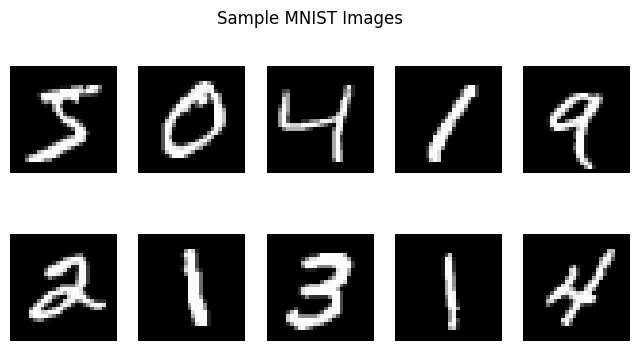

Preprocessed shape: (60000, 28, 28, 1)
Pixel range: -1.0 to 1.0
Dataset preparation completed.


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("Yamini M")
print("24BAD131")
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

print("Number of images:", len(x_train))
print("Image dimensions:", x_train.shape[1:])

plt.figure(figsize=(8, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.axis("off")
plt.suptitle("Sample MNIST Images")
plt.show()

train_images = (x_train.astype("float32") - 127.5) / 127.5

train_images = train_images.reshape(-1, 28, 28, 1)
batch_size = 128
train_dataset = tf.data.Dataset.from_tensor_slices(
    train_images
).shuffle(60000).batch(batch_size)

print("Preprocessed shape:", train_images.shape)
print("Pixel range:", train_images.min(), "to", train_images.max())
print("Dataset preparation completed.")

Yamini M
24BAD131


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 6272)           │       633,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 1)      │         1,025 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 766,401 (2.92 MB)

 Trainable params: 766,017 (2.92 MB)

 Non-trainable params: 384 (1.50 KB)

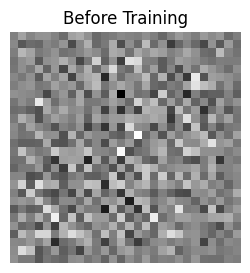

Generator created successfully.


In [ ]:
from tensorflow.keras import layers, models

noise_dim = 100

print("Yamini M")
print("24BAD131")

generator = models.Sequential([
    layers.Input(shape=(noise_dim,)),
    layers.Dense(7 * 7 * 128),
    layers.Reshape((7, 7, 128)),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.2),

    layers.Conv2DTranspose(
        64, 4, strides=2, padding="same"
    ),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.2),

    layers.Conv2DTranspose(
        1, 4, strides=2,
        padding="same", activation="tanh"
    )
])

generator.summary()

noise = tf.random.normal([1, noise_dim])
generated_image = generator(noise, training=False)

plt.figure(figsize=(3, 3))
plt.imshow(generated_image[0, :, :, 0], cmap="gray")
plt.title("Before Training")
plt.axis("off")
plt.show()

print("Generator created successfully.")

In [ ]:
print("Yamini M")
print("24BAD131")

from tensorflow.keras import layers, models

discriminator = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(64, 3, strides=2, padding="same"),
    layers.LeakyReLU(negative_slope=0.2),
    layers.Dropout(0.3),

    layers.Conv2D(128, 3, strides=2, padding="same"),
    layers.LeakyReLU(negative_slope=0.2),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(1, activation="sigmoid")
])

discriminator.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("GENERATOR SUMMARY")
generator.summary()

print("DISCRIMINATOR SUMMARY")
discriminator.summary()

gan_input = layers.Input(shape=(noise_dim,))
fake_image = generator(gan_input)
gan_output = discriminator(fake_image)

gan = models.Model(gan_input, gan_output, name="GAN")

gan.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
    loss="binary_crossentropy"
)

print("GAN SUMMARY")
gan.summary()

print("Discriminator and GAN created successfully.")

Yamini M
24BAD131
GENERATOR SUMMARY


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 6272)           │       633,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 1)      │         1,025 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 766,401 (2.92 MB)

 Trainable params: 766,017 (2.92 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28, 1)      │       766,401 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 1)              │        80,769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 847,170 (3.23 MB)

 Trainable params: 846,786 (3.23 MB)

 Non-trainable params: 384 (1.50 KB)

Discriminator and GAN created successfully.


Epoch 1/5 | Generator Loss: 2.4683 | Discriminator Loss: 0.4531


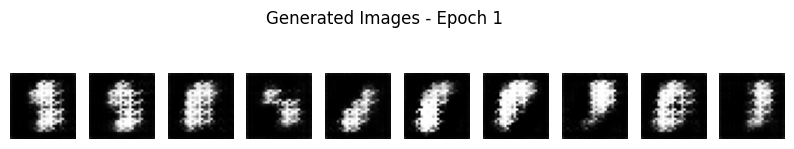

Epoch 2/5 | Generator Loss: 1.7808 | Discriminator Loss: 0.8353


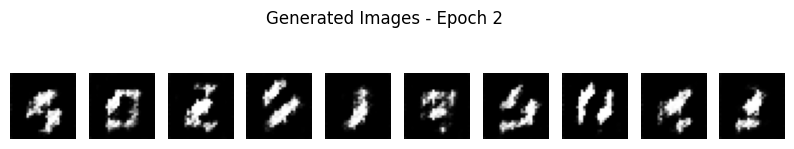

Epoch 3/5 | Generator Loss: 1.4660 | Discriminator Loss: 1.0414


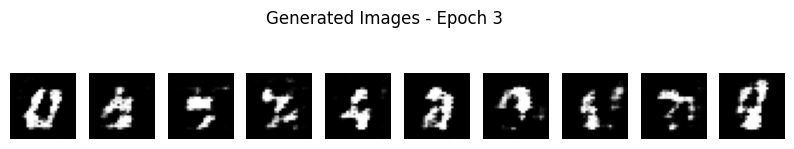

Epoch 4/5 | Generator Loss: 1.2307 | Discriminator Loss: 1.1165


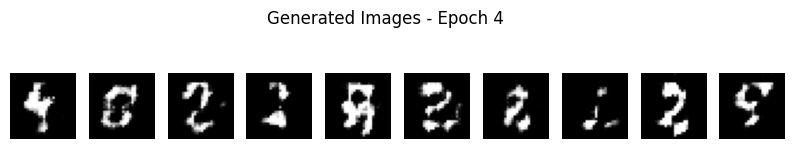

Epoch 5/5 | Generator Loss: 1.0932 | Discriminator Loss: 1.1805


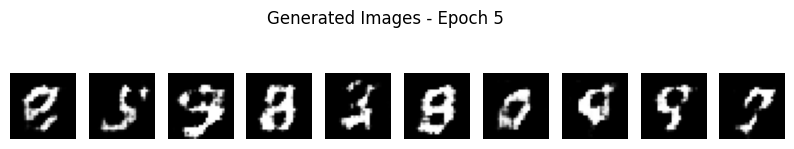

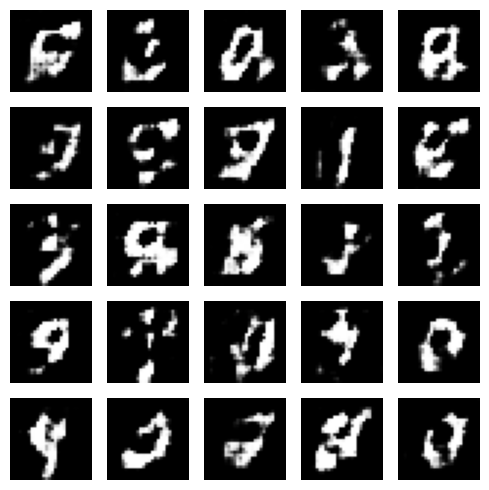

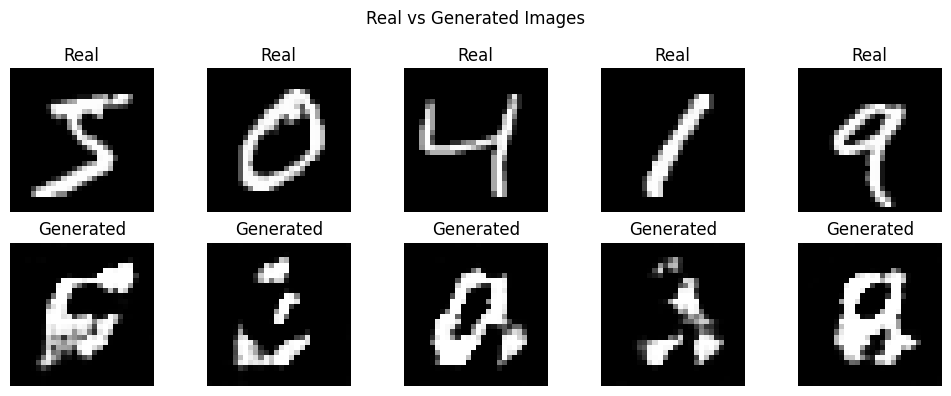

GAN training completed successfully.
Final images saved as generated_images.png
Trained Generator saved as trained_generator.keras


In [ ]:
print("Yamini M")
print("24BAD131")

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

epochs = 5
noise_dim = 100

loss_function = tf.keras.losses.BinaryCrossentropy()

d_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002)
g_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002)

for epoch in range(epochs):
    d_losses = []
    g_losses = []

    for real_images in train_dataset:
        batch_size_now = tf.shape(real_images)[0]

        noise = tf.random.normal([batch_size_now, noise_dim])
        fake_images = generator(noise, training=False)

        with tf.GradientTape() as tape:
            real_output = discriminator(real_images, training=True)
            fake_output = discriminator(fake_images, training=True)

            real_loss = loss_function(
                tf.ones_like(real_output), real_output
            )
            fake_loss = loss_function(
                tf.zeros_like(fake_output), fake_output
            )

            d_loss = real_loss + fake_loss

        d_gradients = tape.gradient(
            d_loss, discriminator.trainable_variables
        )
        d_optimizer.apply_gradients(
            zip(d_gradients, discriminator.trainable_variables)
        )

        noise = tf.random.normal([batch_size_now, noise_dim])

        with tf.GradientTape() as tape:
            fake_images = generator(noise, training=True)
            fake_output = discriminator(fake_images, training=True)

            g_loss = loss_function(
                tf.ones_like(fake_output), fake_output
            )

        g_gradients = tape.gradient(
            g_loss, generator.trainable_variables
        )
        g_optimizer.apply_gradients(
            zip(g_gradients, generator.trainable_variables)
        )

        d_losses.append(float(d_loss))
        g_losses.append(float(g_loss))

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Generator Loss: {np.mean(g_losses):.4f} | "
        f"Discriminator Loss: {np.mean(d_losses):.4f}"
    )

    noise = tf.random.normal([10, noise_dim])
    generated = generator(noise, training=False)

    plt.figure(figsize=(10, 2))
    for i in range(10):
        plt.subplot(1, 10, i + 1)
        plt.imshow(generated[i, :, :, 0], cmap="gray")
        plt.axis("off")

    plt.suptitle(f"Generated Images - Epoch {epoch + 1}")
    plt.show()

noise = tf.random.normal([25, noise_dim])
final_images = generator(noise, training=False)

plt.figure(figsize=(5, 5))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(final_images[i, :, :, 0], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.savefig("generated_images.png")
plt.show()

plt.figure(figsize=(10, 4))

for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i].squeeze(), cmap="gray",
               vmin=-1, vmax=1)
    plt.title("Real")
    plt.axis("off")

    plt.subplot(2, 5, i + 6)
    plt.imshow(final_images[i, :, :, 0], cmap="gray",
               vmin=-1, vmax=1)
    plt.title("Generated")
    plt.axis("off")

plt.suptitle("Real vs Generated Images")
plt.tight_layout()
plt.show()

generator.save("trained_generator.keras")

print("GAN training completed successfully.")
print("Final images saved as generated_images.png")
print("Trained Generator saved as trained_generator.keras")